In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
!mkdir -p pics

**Warning** : Calculation on PROTACpedia records is time consuming. Download the precomputed data would be enough usually.

# Process PROTACpedia structure file

In [ ]:
import os
os.makedirs('data/PDB',exist_ok=True)
from pymol import cmd
import pandas as pd
from detect_pocket import get_pocket_info_from_pdb_info

In [ ]:
pdb_df=pd.read_excel('data/PROTACpedia_pdb.xlsx',sheet_name='pdb_ref',dtype=str)
for idx,(pdbid,ligid,chain_poi,chain_lig,*_) in pdb_df.iterrows():
    try:
        pdbid=pdbid.lower()
        cmd.reinitialize()
        cmd.fetch(pdbid,name=f'{pdbid}',type='cif',path='data/PDB')
    except Exception as e:
        print(e)
        continue
pdb_df[['seq_can', 'boltz_pocket']] = pdb_df.apply(
    lambda row: get_pocket_info_from_pdb_info(
        row['pdbid'], row['ligid'], row['chain_poi'], row['chain_lig'], radius=4
    ), axis=1, result_type='expand')

In [4]:
pedia_df=pd.read_excel('data/PROTACpedia_pdb.xlsx',sheet_name='full_info',)
pdb_refs=pdb_df['UniprotID'].values

def have_pdb_ref(target:str) -> int:
    try:
        targets=target.split(', ')
        for target in targets:
            if target in pdb_refs:
                return 1
        return 0
    except:return 0

pedia_df['have_pdb_ref']=pedia_df['Target'].apply(have_pdb_ref)

In [5]:
def pdb_ref(target:str) -> str:
    try:
        targets=target.split(', ')
        for target in targets:
            if target in pdb_refs:
                return target
        return pd.NA
    except:return pd.NA
pedia_df['pdb_ref']=pedia_df['Target'].apply(pdb_ref)

In [ ]:
from util import smi2inchikey
pedia_df['inchikey']=pedia_df['PROTAC SMILES'].apply(smi2inchikey)

In [7]:
pedia_merge=pedia_df.merge(pdb_df,left_on='pdb_ref',right_on='UniprotID')

In [8]:
pedia_merge['E3 Ligase']=pedia_merge['E3 Ligase'].str.lower().str.replace('cereblon','crbn')
pedia_merge['pdbid']=pedia_merge['pdbid'].str.lower()
pedia_merge[pedia_merge['E3 Ligase'].isin(('vhl','crbn'))].dropna(subset=['pdb_ref','inchikey']).to_csv('data/pedia_extend.csv',index=False)

In [9]:
cmd.reinitialize()
cmd.fetch('8rqa',name='8rqa',type='cif',path='data/PDB')
get_pocket_info_from_pdb_info('8rqa','LVY','A','A',radius=4)

('SAKKPNIINFDTSLPTSHTYLGADMEEFHGRTLHDDDSIQVIPVLPQVMMILVPGQTLPLQLFHPQEVSMVRNLIQNDRTFAVLAYSNVQEREAEFGTTAEIYAYREEQDFGIEIVKVKAIGRQRFKVLELRTQSDGIQQAKVQILPEGSGDAETLMDRIKKQLREWDENLKDDSLPSNPIDFSYWVAANLPIDDSLRIQLLKIDSAIQRLRCELDIMNKCTSLCCKQCQETEITTKNEIFSLSREGPMAAYVNPHGYVHEILTVYKACNLNLIGRPSTEHSWFPGYAWTVAQCKICASHIGWKFTATKKDMSPQKFWGLTRSALIPTI',
 [283, 282, 254, 289, 303, 305, 255, 281, 256])

In [10]:
cmd.reinitialize()
cmd.fetch('6gfy',name='6gfy',type='cif',path='data/PDB')
get_pocket_info_from_pdb_info('6gfy','EXH','C','C',radius=4)

('GSMEAGRPRPVLRSVNSREPSQVIFCNRSPRVVLPVWLNFDGEPQPYPTLPPGTGRRIHSYRGHLWLFRDAGTHDGLLVNQTELFVPSLNVDGQPIFANITLPVYTLKERCLQVVRSLVKPENYRRLDIVRSLYEDLEDHPNVQKDLERLTQERIAHQRMGD',
 [59, 66, 64, 47, 61, 48, 60, 37, 58, 40])

# Get boltz MSA files

In [13]:
import shutil
from util import get_a3m
os.makedirs('data/MSA',exist_ok=True)
for _,(pdbid,seq) in pdb_df[['pdbid','seq_can',]].iterrows():
    pdbid=pdbid.lower()
    get_a3m(seq,'data/MSA/'+pdbid)

In [14]:
!rm -r data/MSA/*_env
!rm data/MSA/*_tmp.a3m

zsh:1: no matches found: data/MSA/*_env
zsh:1: no matches found: data/MSA/*_tmp.a3m


In [16]:
get_a3m('SAKKPNIINFDTSLPTSHTYLGADMEEFHGRTLHDDDSIQVIPVLPQVMMILVPGQTLPLQLFHPQEVSMVRNLIQNDRTFAVLAYSNVQEREAEFGTTAEIYAYREEQDFGIEIVKVKAIGRQRFKVLELRTQSDGIQQAKVQILPEGSGDAETLMDRIKKQLREWDENLKDDSLPSNPIDFSYWVAANLPIDDSLRIQLLKIDSAIQRLRCELDIMNKCTSLCCKQCQETEITTKNEIFSLSREGPMAAYVNPHGYVHEILTVYKACNLNLIGRPSTEHSWFPGYAWTVAQCKICASHIGWKFTATKKDMSPQKFWGLTRSALIPTI','data/MSA/8rqa')
get_a3m('GSMEAGRPRPVLRSVNSREPSQVIFCNRSPRVVLPVWLNFDGEPQPYPTLPPGTGRRIHSYRGHLWLFRDAGTHDGLLVNQTELFVPSLNVDGQPIFANITLPVYTLKERCLQVVRSLVKPENYRRLDIVRSLYEDLEDHPNVQKDLERLTQERIAHQRMGD','data/MSA/6gfy')

In [18]:
import shutil
shutil.copy('data/MSA/8rqa.a3m','data/MSA/crbn.a3m')
shutil.copy('data/MSA/6gfy.a3m','data/MSA/vhl.a3m')

'data/MSA/vhl.a3m'

# Precompute

- takes about 1h on precomputed data (extract_from_precomputed=True), or 30h from empty directory
- skip to next section if you don't want to do this step
- or run `python precompute.py` in shell.

In [ ]:
import pandas as pd
from reinvent_plugins.components.boltz_interface import calculate_affinity_score
from ast import literal_eval
pedia_extend=pd.read_csv('data/pedia_extend.csv',header='infer')

import os
os.environ.setdefault('BOLTZ_CACHE','~/projects/boltz')
# change it to your boltz cache dir 

In [ ]:
tmp_result=[]
for lig_smi,inchikey,name_poi,seq_poi,pocket_poi,name_e3 in pedia_extend[['PROTAC SMILES','inchikey','pdbid','seq_can','boltz_pocket','E3 Ligase']].itertuples(False):
    tmp_result.extend(calculate_affinity_score(lig_smi,inchikey,name_poi,seq_poi,literal_eval(pocket_poi),name_e3,extract_from_precomputed=True))
    # change `extract_from_precomputed` to False if you want to recalculate

In [33]:
sc_df=pd.DataFrame(tmp_result,columns=['pdbid','E3 Ligase','inchikey','lgKd_poi','lgKd_e3','lgKd_ternary','ref_model','dist_ub','has_surf_lys','bsa','num_clash','lys_site_boltz'])
sc_df=sc_df.astype({'lgKd_poi':float,'lgKd_e3':float,'lgKd_ternary':float,'ref_model':str,'dist_ub':float,'has_surf_lys':int,'bsa':float,'num_clash':float,'lys_site_boltz':int})
sc_df=sc_df[sc_df['lgKd_ternary']!=float('inf')]

In [34]:
pedia_precompute=pd.merge(pedia_extend,sc_df,on=['pdbid', 'E3 Ligase', 'inchikey'], how='inner').drop_duplicates(['pdbid', 'E3 Ligase', 'inchikey','ref_model'],keep='first') # activity in different cells are different records
pedia_precompute['Active/Inactive']=(pedia_precompute['Active/Inactive']=='Active').astype(int)
pedia_precompute['lg_alpha']=pedia_precompute['lgKd_poi']+pedia_precompute['lgKd_e3']-pedia_precompute['lgKd_ternary']
pedia_precompute.astype({'PROTACDB ID':int}).to_csv('data/pedia_precompute.csv',index=False)
# verbose results with inner scores

## Annotate PTM sites

In [ ]:
from util import update_all_uniprot_ptm_info,update_uniprot_uid2seq,idxmaps
import pandas as pd

uniprot_ids=pd.read_excel('data/PROTACpedia_pdb.xlsx','pdb_ref')['UniprotID']
dfs=update_all_uniprot_ptm_info(uniprot_ids)
df_uniprot_id2seq=update_uniprot_uid2seq(uniprot_ids)
df_pedia_precompute=pd.read_csv('data/pedia_precompute.csv',header='infer')
df_seq_pair = df_pedia_precompute[['UniprotID','seq_can']].merge(
    df_uniprot_id2seq[['UniprotID', 'seq']],
    left_on='UniprotID',
    right_on='UniprotID',
    how='inner'
).rename(columns={'seq': 'seq_uniprot','seq_can':'seq_boltz'}) # remove seq_uniprot after annotation

In [54]:
df_seq_pair_copy=df_seq_pair.drop_duplicates(['seq_boltz','seq_uniprot']).dropna(subset=['seq_boltz','seq_uniprot'])
df_idxmaps=idxmaps(zip(df_seq_pair_copy['seq_boltz'],df_seq_pair_copy['seq_uniprot']))

In [57]:
df_pedia_ptm_annotated=df_pedia_precompute.sort_values('dist_ub').drop_duplicates(['pdbid', 'E3 Ligase', 'inchikey'],keep='first')
df_pedia_ptm_annotated=df_pedia_ptm_annotated.merge(df_idxmaps,how='inner',left_on=['seq_can'],right_on=['seq_boltz'])
df_pedia_ptm_annotated['lys_site_uniprot']=df_pedia_ptm_annotated.apply(
    lambda row:row['idxmap'].get(row['lys_site_boltz']),axis=1)

In [61]:
df_uid2evidence=pd.read_csv('data/ub_site/uniprot_evidences.csv',header='infer')
df_pedia_ptm_annotated=df_pedia_ptm_annotated.merge(df_uid2evidence,how='left',left_on=['UniprotID','lys_site_uniprot'],right_on=['UniprotID','uniprot_lys_resid'])

In [63]:
df_pedia_ptm_annotated.astype({'PROTACDB ID':int})[[col for col in df_pedia_ptm_annotated.columns if col in ['PROTACDB ID','Active/Inactive','protein_name','UniprotID','E3 Ligase','lys_site_uniprot','evidence_score']]].to_csv('data/pedia_ptm_annotated.csv',index=False)

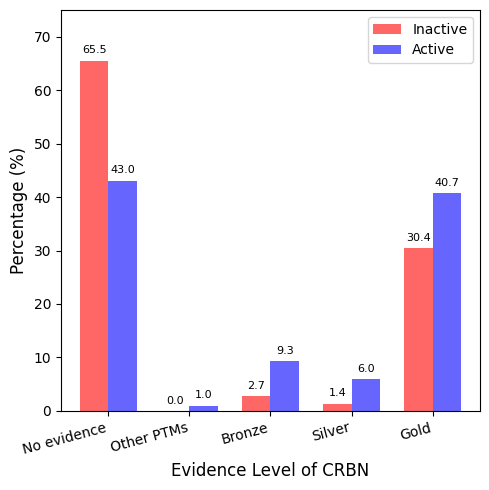

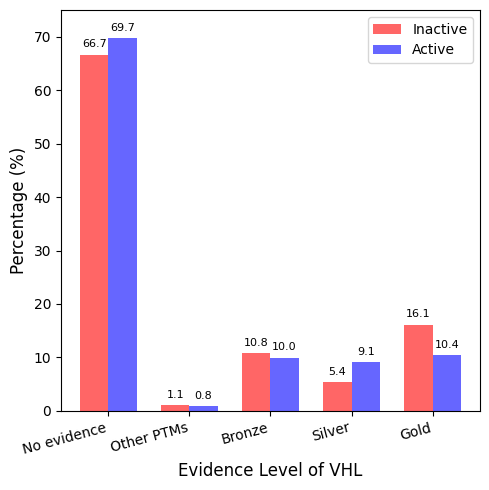

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

evidence_labels = {
    0: 'No evidence',
    1: 'Other PTMs', 
    2: 'Bronze',
    3: 'Silver',
    4: 'Gold'
}

def calculate_evidence_distribution_by_ligase(df):
    results = []
    for ligase in df['E3 Ligase'].unique():
        df_ligase = df[df['E3 Ligase'] == ligase]
        for activity in [0, 1]:
            subset = df_ligase[df_ligase['Active/Inactive'] == activity]
            total = len(subset)
            activity_name = 'Active' if activity == 1 else 'Inactive'
            
            for score in sorted(df['evidence_score'].unique()):
                count = len(subset[subset['evidence_score'] == score])
                pct = (count / total * 100) if total > 0 else 0
                results.append({
                    'E3_Ligase': ligase.upper(),
                    'Activity': activity_name,
                    'evidence_score': score,
                    'evidence_label': evidence_labels[score],
                    'Percentage': pct
                })
    return pd.DataFrame(results)

plot_df_ligase = calculate_evidence_distribution_by_ligase(df_pedia_ptm_annotated)
for ligase in plot_df_ligase['E3_Ligase'].unique():
    fig, ax = plt.subplots(figsize=(5, 5))
    subset = plot_df_ligase[plot_df_ligase['E3_Ligase'] == ligase]
    x = np.arange(len(evidence_labels))
    width = 0.35
    inactive_data = subset[subset['Activity'] == 'Inactive']
    active_data = subset[subset['Activity'] == 'Active']
    
    bars1 = ax.bar(x - width/2, inactive_data['Percentage'], width, 
                   label='Inactive', color='red',alpha=0.6)
    bars2 = ax.bar(x + width/2, active_data['Percentage'], width, 
                   label='Active', color='blue',alpha=0.6)
    
    ax.set_xlabel(f'Evidence Level of {ligase.upper()}', fontsize=12)
    ax.set_ylabel('Percentage (%)', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(list(evidence_labels.values()), rotation=15, ha='right')
    ax.legend()
    ax.set_ylim(0, 75)
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                       f'{height:.1f}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    if ligase == 'CRBN':
        plt.savefig('pics/evidence_crbn.png', dpi=600, bbox_inches='tight')
    elif ligase == 'VHL':
        plt.savefig('pics/evidence_vhl.png', dpi=600, bbox_inches='tight')
    plt.show()

# Train scoring weights

In [91]:
import pandas as pd
pedia_precompute=pd.read_csv('data/pedia_precompute.csv',header='infer')
pedia_precompute=pedia_precompute[(abs(pedia_precompute['lg_alpha'])!=float('inf'))&(~pedia_precompute['lg_alpha'].isna())]
pedia_precompute['dist_ub_square']=pedia_precompute['dist_ub']**2
len(pedia_precompute)

4346

In [81]:
test_df=pedia_precompute.copy()
test_df=test_df.sort_values(by='dist_ub_square')
test_df=test_df.drop_duplicates(['pdbid', 'E3 Ligase', 'inchikey'],keep='first')

In [82]:
test_df[test_df['E3 Ligase']=='crbn']['ref_model'].value_counts()

ref_model
model12_clean.pdb    107
model9_clean.pdb      94
model1_clean.pdb      82
model2_clean.pdb      51
model4_clean.pdb      45
model5_clean.pdb      32
model3_clean.pdb      31
model10_clean.pdb      3
model11_clean.pdb      1
Name: count, dtype: int64

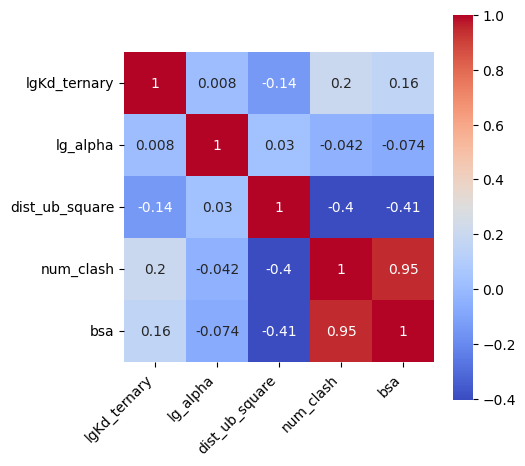

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
ax=sns.heatmap(test_df[['lgKd_ternary', 'lg_alpha', 'dist_ub_square', 'num_clash', 'bsa']].corr(), annot=True, cmap='coolwarm')
ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha='right');
ax.set_aspect('equal')
plt.savefig('pics/features.png',dpi=600,bbox_inches='tight')

In [84]:
import pandas as pd
import numpy as np
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold,cross_val_score
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')
def train_linercv_weight(df,feature_cols:list[str], scaler=None):
    target_col = 'Active/Inactive'
    X = df[feature_cols]
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)
    if scaler is None:
        X_train_scaled = X_train
        X_test_scaled = X_test
    else:
        s = scaler()
        X_train_scaled = s.fit_transform(X_train)
        X_test_scaled = s.transform(X_test)
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    cv_ridge = cross_val_score(RidgeClassifier(class_weight='balanced'), X_train_scaled, y_train, 
                         scoring='roc_auc', cv=skf)
    print(f'Ridge train set ROC-AUC: {float(np.mean(cv_ridge)):.4f} ± {float(np.std(cv_ridge)):.4f}')
    ridge_final = RidgeClassifier(class_weight='balanced')
    ridge_final.fit(X_train_scaled, y_train)
    y_test_scores = ridge_final.decision_function(X_test_scaled)
    print(f'Ridge test set ROC-AUC: {roc_auc_score(y_test, y_test_scores):.4f}')
    print('Ridge coefficients:')
    coef = ridge_final.coef_
    if coef.ndim > 1:
        coef = coef[0]
    for feat, coef_val in zip(feature_cols, coef):
        print(f'  {feat}: {coef_val:.4f}')
    intercept = ridge_final.intercept_
    if hasattr(intercept, '__iter__') and not isinstance(intercept, (str, bytes)):
        intercept = intercept[0]
    print(f'  intercept: {intercept:.4f}\n')
    
    return ridge_final,X_test_scaled,y_test,s

In [104]:
models = train_linercv_weight(test_df,['lgKd_ternary','dist_ub_square','num_clash'], QuantileTransformer)

Ridge train set ROC-AUC: 0.5680 ± 0.0413
Ridge test set ROC-AUC: 0.5413
Ridge coefficients:
  lgKd_ternary: -0.3934
  dist_ub_square: -0.1073
  num_clash: -0.2826
  intercept: 0.3731



In [86]:
test_df['group_mean'] = test_df.groupby('pdbid')['Active/Inactive'].transform('mean')

In [87]:
test_df[(test_df['group_mean'] > 0.25) & (test_df['group_mean'] < 0.75)].value_counts('pdbid').head()

pdbid
2gqg    69
3ika    49
5eu1    46
1r5k    40
1hwk    39
Name: count, dtype: int64

In [88]:
!mkdir -p pics

In [89]:
from sklearn.metrics import auc, roc_curve
import matplotlib.pyplot as plt

def print_roc(models_data):
    plt.figure(figsize=(5, 5))
    colors = plt.cm.Set2(np.linspace(0, 1, len(models_data)))
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    for (name, y_test_truth, y_test_predict,linestyle,user_color), color in zip(models_data, colors):
        fpr, tpr, thresholds = roc_curve(y_test_truth, y_test_predict)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=user_color if user_color else color, lw=2, linestyle=linestyle, label=f'{name} (AUC = {roc_auc:.3f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    plt.legend(loc="lower right", fontsize=10)
    plt.tight_layout()
    plt.savefig('pics/roc.png',dpi=600,bbox_inches='tight')
    plt.show()

In [95]:
model_2gqg = train_linercv_weight(test_df[test_df['pdbid']=='2gqg'],['lgKd_ternary','dist_ub_square','bsa'], QuantileTransformer)
model_3ika = train_linercv_weight(test_df[test_df['pdbid']=='3ika'],['lgKd_ternary','dist_ub_square','num_clash'], QuantileTransformer)

Ridge train set ROC-AUC: 0.7800 ± 0.1360
Ridge test set ROC-AUC: 0.7708
Ridge coefficients:
  lgKd_ternary: -0.6912
  dist_ub_square: -0.1498
  bsa: 1.1096
  intercept: -0.0013

Ridge train set ROC-AUC: 0.8200 ± 0.2509
Ridge test set ROC-AUC: 0.8095
Ridge coefficients:
  lgKd_ternary: -1.7983
  dist_ub_square: -0.4033
  num_clash: -0.0411
  intercept: 1.2341



In [96]:
import joblib
joblib.dump(models[3],'data/scaler.pkl')

['data/scaler.pkl']

In [97]:
sc_active=3/((1/(1-models[3].transform(test_df[test_df['Active/Inactive']==1][['lgKd_ternary','dist_ub_square','num_clash']]))).sum(axis=1))
np.percentile(sc_active, 50),np.mean(sc_active),np.std(sc_active),

(0.3580756830200262, 0.3664318157168941, 0.19316997065043243)

In [98]:
sc_inact=3/((1/(1-models[3].transform(test_df[test_df['Active/Inactive']==0][['lgKd_ternary','dist_ub_square','num_clash']]))).sum(axis=1))
np.percentile(sc_inact, 50),np.mean(sc_inact),np.std(sc_inact),

(0.30606540475289146, 0.30709618497646907, 0.19372145619534353)

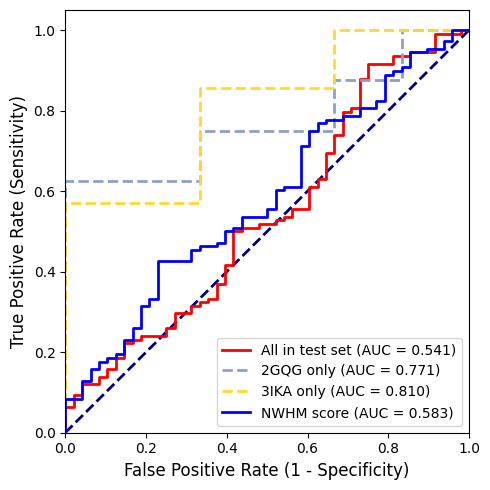

In [99]:
print_roc([('All in test set',models[2],models[0].decision_function(models[1]),'-','red'),
('2GQG only',model_2gqg[2],model_2gqg[0].decision_function(model_2gqg[1]),'--',''),
('3IKA only',model_3ika[2],model_3ika[0].decision_function(model_3ika[1]),'--',''),
('NWHM score',models[2],3/((1/(1-models[1])).sum(axis=1)),'-','blue'),
])

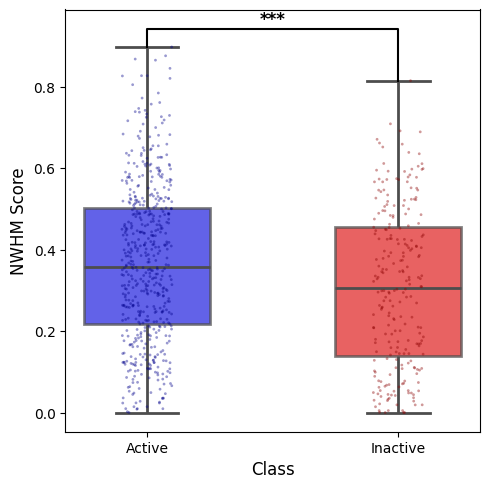

Active scores: mean=0.366, median=0.358, std=0.193
Inactive scores: mean=0.307, median=0.306, std=0.194
Mean difference: 0.059
Mann-Whitney U test p-value: 2.54e-04


In [106]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import  mannwhitneyu

def plot_boxplot_with_stats(scores_active, scores_inactive):
    data = pd.DataFrame({
        'NWHM Score': np.concatenate([scores_active, scores_inactive]),
        'Class': ['Active'] * len(scores_active) + ['Inactive'] * len(scores_inactive)
    })
    fig, ax = plt.subplots(figsize=(5, 5))
    sns.boxplot(x='Class', y='NWHM Score', data=data, palette={'Active':'blue', 'Inactive':'red'}, 
                width=0.5, ax=ax, fliersize=3, linewidth=2, boxprops={'alpha':0.7})
    sns.stripplot(x='Class', y='NWHM Score', data=data, palette={'Active':'darkblue', 'Inactive':'darkred'}, 
                  size=2, alpha=0.4, jitter=True, ax=ax)
    stat, p_value_mw = mannwhitneyu(scores_active, scores_inactive, alternative='two-sided')
    x1, x2 = 0, 1 
    y1 = scores_active.max()
    y2 = scores_inactive.max()
    y_max = max(y1, y2)
    y_h = y_max * 0.05
    ax.plot([x1, x1, x2, x2], [y1, y_max + y_h, y_max + y_h, y2], 
            lw=1.5, color='black')
    if p_value_mw < 0.001:
        p_text = '***'
    elif p_value_mw < 0.01:
        p_text = '**'
    elif p_value_mw < 0.05:
        p_text = '*'
    else:
        p_text = f'p = {p_value_mw:.2e}'
    ax.text((x1 + x2) / 2, y_max + y_h, p_text, ha='center', va='bottom', 
            fontsize=12, fontweight='bold')
    
    ax.set_xlabel('Class', fontsize=12)
    ax.set_ylabel('NWHM Score', fontsize=12)
    plt.tight_layout()
    plt.savefig('pics/NWHM_box.png',dpi=600,bbox_inches='tight')
    plt.show()
    print(f"Active scores: mean={scores_active.mean():.3f}, median={np.median(scores_active):.3f}, std={scores_active.std():.3f}")
    print(f"Inactive scores: mean={scores_inactive.mean():.3f}, median={np.median(scores_inactive):.3f}, std={scores_inactive.std():.3f}")
    print(f"Mean difference: {scores_active.mean() - scores_inactive.mean():.3f}")
    print(f"Mann-Whitney U test p-value: {p_value_mw:.2e}")
plot_boxplot_with_stats(sc_active, sc_inact)